<a href="https://colab.research.google.com/github/IcaroBedinotto-bed/tech-challegenge-grupo-47/blob/main/Tech_Challenge_%7C_Fase_1_1IAST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entendimento dos dados e garantir de disponibilidade

Primeiramente, faz-se necessário compreender quais são os dados disponíveis, como podemos manipulá-los e por verificar se existem gaps que precisam ser tratados

In [ ]:
"""
    Carregar as bibliotecas básicas para análise de dados e exploração
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("desafio_nps.csv")

In [ ]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
df.isna().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


Até aqui já é possível compreender todas as colunas que existem dentro do dataframe e também garantir que não existem valores nulos, o que retira a necessidade de um primeiro tratamento quanto a dados vazios e nulos.

In [ ]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [ ]:
df["customer_id"].nunique()


2500

In [ ]:
df["order_id"].nunique()

2500

Dada a estatísticas acima, foi possível verificar que nenhum registro está desalinhado dos demais, dessa forma não há necessidade de tratamento. Além disso, cada registro é único.



---



# Impacto dos indicadores de satifação

Agora queremos entender qual é o impacto relacionado a piores indicadores de NPS. Com base em informações externas, verificou-se forte impacto na retenção dos usuários.

CSAT também é uma medida de satisfação do cliente, porém segundo o dicionário da tabela, essa métrica é interna da empresa, logo pode ser uma estimativa, não sendo levada em consideração e restringindo a análise ao NPS.

<img src="https://neilpatel.com/wp-content/uploads/2019/05/calculo-de-nps.jpeg" width="500" height="auto">

[Fonte da imagem](https://neilpatel.com/wp-content/uploads/2019/05/calculo-de-nps.jpeg)

In [ ]:
df["nps_categoria"] = np.where(
    df["nps_score"] >= 9, "Promoter",
    np.where(df["nps_score"] >= 7, "Passive", "Detractor")
)

In [ ]:
df["usuario_retido"] = np.where(
    df["repeat_purchase_30d"] > 0, "True", "False"
)

In [ ]:
retencao_categoria = df.groupby(["nps_categoria", "usuario_retido" ])["order_id"].nunique()

percentual_retido = retencao_categoria / retencao_categoria.groupby(level=0).sum()*100

percentual_retido

nps_categoria  usuario_retido
Detractor      False             100.000000
Passive        False              61.565836
               True               38.434164
Promoter       True              100.000000
Name: order_id, dtype: float64

### Impacto do NPS na retenção

* Usuário detrator = Não será retido;
* Usuário passivo = 38% são retidos;
* Usuário promotor = 100% são retidos

**Resultado:** Para esse e-commerce o NPS é um ótimo indicador para mostrar a renteção do usuário em 30 dias.




---



# Quais variáveis se correlacionam com NPS?

In [ ]:
pearson = df.corr(numeric_only=True, method="pearson")
spearman = df.corr(numeric_only=True, method="spearman")

comparacao = pd.concat(
    [pearson[["nps_score"]], spearman[["nps_score"]]],
    axis=1,
    keys=["pearson", "spearman"]
)

comparacao

,pearson,spearman
,nps_score,nps_score
customer_id,0.015162,0.016058
customer_age,-0.009936,-0.007441
customer_tenure_months,-0.009711,-0.011649
order_id,0.015162,0.016058
order_value,0.036990,0.035891
items_quantity,0.011468,0.006241
discount_value,0.025104,0.011567
payment_installments,0.023718,0.026660
delivery_time_days,0.000925,0.000299


Afim de reduzir o processo, já analisamos a correlação das variáveis utilizando tanto Pearson quanto Spearman.

**NPS correlaciona-se com :**

*   repeat_purchase_30d (0,57 | Pearson e 0,49 | Spearman):  Corrobora com os dados que já trouxemos que mostram que maior nível de NPS aumenta a probabilidade de recompra após 30 dias;

*   customer_service_contacts (-0,35 | Pearson e -0,34 | Spearman): Correlação moderada e negativa, mas já chama a atenção e pode mostrar que usuários que mais fazem contato podem ser detratores da marca, podendo indicar problema no atendimento;

*   Complaints_count (-0,50 | Pearson e -0,49 | Spearman): Correlação forte e negativa, podendo indicar que usuários que mais abrem reclamação são mais insatisfeitos, podendo indicar problema de atendimento e não tratativa correta;

*   delivery_delay_days (-0,60 | Pearson e -0,59 | Spearman): Correlação forte e negativa, o que pode indicar que pedidos com maior tempo de entrega impactam negativamente na satisfação do cliente



[Fonte para definição do nível de correlação](https://www.scribbr.com/statistics/pearson-correlation-coefficient/)

In [ ]:
corr = df.corr(numeric_only=True)

corr_targets = corr[["customer_service_contacts", "complaints_count", "delivery_delay_days"]].sort_values(by="delivery_delay_days", ascending=False)
corr_targets

,customer_service_contacts,complaints_count,delivery_delay_days
delivery_delay_days,-0.024167,0.190225,1.000000
complaints_count,0.754617,1.000000,0.190225
order_value,0.032823,0.001893,0.005971
delivery_attempts,-0.012063,-0.006905,0.005189
freight_value,0.024790,0.022673,0.003779
customer_tenure_months,-0.008960,-0.009167,0.001198
customer_age,0.032706,0.008211,-0.002094
delivery_time_days,0.007706,-0.008998,-0.006589
items_quantity,-0.014553,0.024986,-0.014567
resolution_time_days,0.014678,0.018057,-0.015297


In [ ]:
percentual_reclamacao = df[(df["customer_service_contacts"] >= 1) & (df["delivery_delay_days"] >= 1)].shape[0] / df[df["delivery_delay_days"] >= 1].shape[0]
percentual_reclamacao

0.7800269905533064

In [ ]:
percentual_atraso = df[df["delivery_delay_days"] >= 1].shape[0] / df["order_id"].nunique()*100
percentual_atraso

88.92

<Axes: >

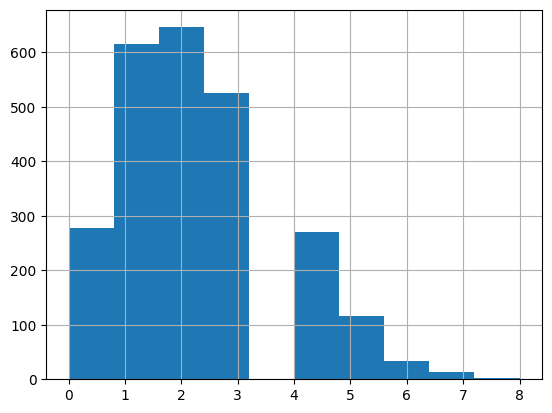

In [ ]:
df["delivery_delay_days"].hist()

A correlação entre as três variáveis que tendem a impactar diretamente o NPS indicam que:

*   O usuário que registra reclamação tende a fazer contato com a empresa, indicando provavelmente a preferência por algum canal;

*   Correlação fraca entre o atraso do pedido e o registro de reclamações e contato entre empresa e cliente, mesmo o atraso do pedido sendo um ofensor de NPS. Ou seja, o usuário tem um problema, mas não faz contato com a empresa e nem recebe contato, o que indica um gap no processo, devendo ser um ponto de ação aqui. Dessa forma, **se for registrado o atraso da entrega, a empresa deve agir de maneira proativa com o cliente evitando ofensores e queda de retenção.**





---



# Qual o comportamento das variáveis por grupos?

### Novas perguntas

*   Já é de conhecimento que atraso no pedido é ofensor, existe alguma região que concentra a maior dos atrasos? - Podendo indicar necessidade de investimento

*  Já sabemos que muitas vezes os usuários que possuem atraso no pedido não registram a reclamação, existe alguma região que concentra isso? - Podendo indicar necessidade de novos canais de comunicação para atender todas as regiões do Brasil


### O que pode estar acontecendo?
A pesquisa acontece no final da jornada do usuário, ou seja, o cliente passou por todos os problemas possiveis e depois disso ele é questionado, indicando que a empresa nunca age de forma proativa e a baixa correlação entre tempo de atraso na entrega e reclamações registradas, mesmo o atraso sendo uma variável ofensora corrobora para a tese

In [ ]:
"""
    Compreender qual o NPS da empresa de forma geral
"""
dist = df["nps_categoria"].value_counts(normalize=True)

nps = (dist.get("Promoter", 0) - dist.get("Detractor", 0)) * 100

nps


np.float64(-79.96)

In [ ]:
"""
  Entender o % de usuários retidos após 30 dias

"""

df.groupby("usuario_retido")["order_id"].nunique()/df["order_id"].nunique()*100

,order_id
usuario_retido,
False,91.28
True,8.72


Ou seja, a empresa apresenta um NPS de -79,96% e uma retenção depois de 30 dias de 8,72%

In [ ]:
df_semId = df.drop(columns=["customer_id", "order_id"])

df_semId.groupby("customer_region").mean(numeric_only=True)

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
customer_region,,,,,,,,,,,,,,,,
Centro-Oeste,43.397436,61.213675,444.664380,3.393162,29.921795,5.948718,7.912393,2.222222,37.872329,2.000000,1.591880,5.241453,4.209829,0.083333,4.177350,3.022009
Nordeste,44.020619,59.847423,443.623320,3.573196,30.248948,6.136082,8.160825,2.185567,37.254887,2.014433,1.507216,5.327835,4.421649,0.076289,4.162887,3.024124
Norte,43.369565,61.602767,434.571047,3.434783,28.813972,6.043478,7.758893,2.144269,38.975079,1.978261,1.456522,5.747036,4.382609,0.079051,4.110672,2.935375
Sudeste,42.886538,61.851923,413.531000,3.471154,30.666538,5.932692,8.201923,2.217308,38.504442,2.036538,1.494231,5.450000,4.373846,0.088462,4.242308,2.931538
Sul,43.347409,61.992322,436.583570,3.479846,29.104491,5.963532,8.067179,2.168906,38.399175,1.998081,1.552783,5.633397,4.490979,0.107486,4.061420,2.808637


In [ ]:
df.groupby("customer_region").agg(
    total_revenue=("order_value", "sum"),
    pedidos_unicos=("order_id", "nunique")
).assign(
    ticket_medio=lambda x: x["total_revenue"] / x["pedidos_unicos"]
)

,total_revenue,pedidos_unicos,ticket_medio
customer_region,,,
Centro-Oeste,208102.93,468,444.664380
Nordeste,215157.31,485,443.623320
Norte,219892.95,506,434.571047
Sudeste,215036.12,520,413.531000
Sul,227460.04,521,436.583570


Sudeste
* Menor order_value
* Maior tempo de entrega

Nordeste
* Menor tempo de relacionamento com os clientes

Centro-oeste
* Maior tempo médio de atraso
* Maior número de contatos
* Menor NPS
* Menor volume de pedidos, mas maior Ticket-médio
* Menor receita

Sul
* Maior volume de receita e pedidos

In [ ]:
grouped = df.groupby(["customer_region", "nps_categoria"])["order_id"].nunique()

percentual = grouped / grouped.groupby(level=0).sum() * 100

nps_por_regiao = (
    percentual.unstack(fill_value=0)
    .assign(NPS=lambda x: x.get("Promoter", 0) - x.get("Detractor", 0))
)

nps_por_regiao

nps_categoria,Detractor,Passive,Promoter,NPS
customer_region,,,,
Centro-Oeste,84.188034,10.470085,5.341880,-78.846154
Nordeste,85.567010,10.103093,4.329897,-81.237113
Norte,85.177866,11.264822,3.557312,-81.620553
Sudeste,83.653846,11.923077,4.423077,-79.230769
Sul,83.301344,12.284069,4.414587,-78.886756


In [ ]:
grouped = df.groupby(["customer_region", "usuario_retido"])["order_id"].nunique()

percentual = grouped / grouped.groupby(level=0).sum()*100

percentual

customer_region  usuario_retido
Centro-Oeste     False             91.666667
                 True               8.333333
Nordeste         False             92.371134
                 True               7.628866
Norte            False             92.094862
                 True               7.905138
Sudeste          False             91.153846
                 True               8.846154
Sul              False             89.251440
                 True              10.748560
Name: order_id, dtype: float64

O volume total de detratores é extremamente alto, ultrapassando  83% em todas as regiões, Norte e Nordeste possuem mais 85% dos usuários como detratores e Centro-Oeste mais de 84%. Além disso, o nível de recompra nos últimos 30 dias é menor que 11% em todas as regiões.